# Análise Exploratória — Ações B3 x Indicadores Macro

Objetivo: explorar os dados tratados de cotações da B3, Selic e IPCA para entender o comportamento dos ativos, sua volatilidade e possíveis relações com o cenário macroeconômico.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

df = pd.read_csv("../data/processed/dados_tratados.csv")
df["ano_mes"] = pd.PeriodIndex(df["ano_mes"], freq="M")

print(f"Linhas: {len(df)} | Meses: {df['ano_mes'].nunique()} | Tickers: {df['ticker'].nunique()}")
df.head()

Linhas: 488 | Meses: 61 | Tickers: 8


,ano_mes,ticker,preco_fechamento,retorno_mensal_pct,selic_media,ipca_variacao
0,2021-08,ABEV3.SA,13.063990,NaN,5.250000,0.87
1,2021-09,ABEV3.SA,11.688833,-10.526313,5.516667,1.16
2,2021-10,ABEV3.SA,12.979953,11.045752,6.443548,1.25
3,2021-11,ABEV3.SA,12.269454,-5.473817,7.750000,0.95
4,2021-12,ABEV3.SA,12.240264,-0.237908,8.862903,0.73


## Estatísticas descritivas

Retorno médio mensal, volatilidade (desvio padrão do retorno) e retorno acumulado no período, por ticker.

In [2]:
def retorno_acumulado(series):
    r = series.dropna() / 100
    return ((1 + r).prod() - 1) * 100

stats = df.groupby("ticker").agg(
    retorno_medio_pct=("retorno_mensal_pct", "mean"),
    volatilidade_pct=("retorno_mensal_pct", "std"),
).reset_index()

acum = df.groupby("ticker")["retorno_mensal_pct"].apply(retorno_acumulado).reset_index()
acum.columns = ["ticker", "retorno_acumulado_pct"]
stats = stats.merge(acum, on="ticker")

stats = stats.sort_values("retorno_acumulado_pct", ascending=False).reset_index(drop=True)
stats.style.format({
    "retorno_medio_pct": "{:.2f}%",
    "volatilidade_pct": "{:.2f}%",
    "retorno_acumulado_pct": "{:.1f}%",
}).set_caption("Estatísticas por ticker (últimos 5 anos)")

,ticker,retorno_medio_pct,volatilidade_pct,retorno_acumulado_pct
0,PETR4.SA,3.15%,8.94%,415.5%
1,CPFE3.SA,1.45%,5.82%,115.0%
2,ITUB4.SA,1.46%,7.89%,98.7%
3,WEGE3.SA,1.15%,8.84%,58.4%
4,^BVSP,0.77%,5.02%,47.0%
5,VALE3.SA,0.79%,8.08%,32.7%
6,ABEV3.SA,0.42%,5.75%,16.7%
7,MGLU3.SA,-3.57%,21.45%,-97.0%


## Evolução dos preços

Preço de fechamento normalizado em base 100 (primeiro mês = 100) para facilitar a comparação entre ativos de escalas diferentes.

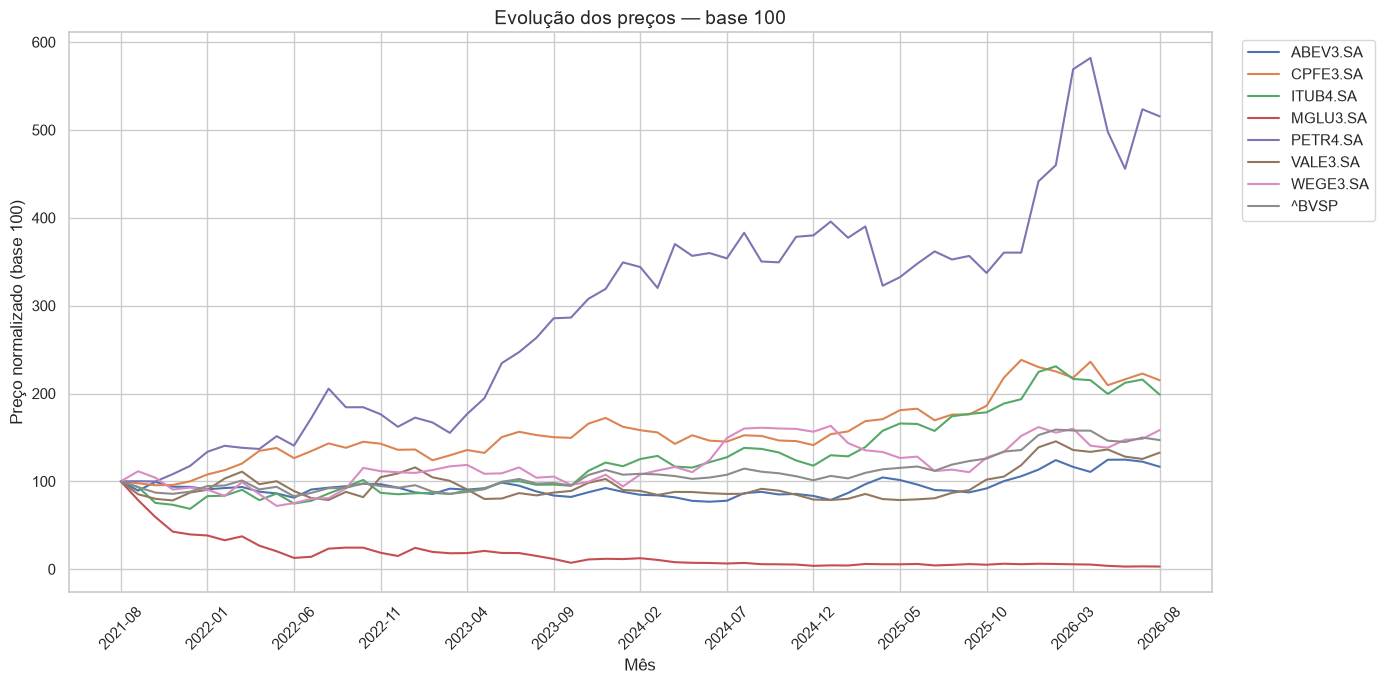

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))

for ticker, grupo in df.groupby("ticker"):
    grupo = grupo.sort_values("ano_mes")
    base = grupo["preco_fechamento"].iloc[0]
    normalizado = grupo["preco_fechamento"] / base * 100
    ax.plot(grupo["ano_mes"].astype(str), normalizado, label=ticker, linewidth=1.5)

ax.set_title("Evolução dos preços — base 100", fontsize=14)
ax.set_ylabel("Preço normalizado (base 100)")
ax.set_xlabel("Mês")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)
ax.xaxis.set_major_locator(plt.MaxNLocator(15))
plt.tight_layout()
plt.show()

## Selic e IPCA ao longo do tempo

Evolução da meta Selic (média mensal) e da variação mensal do IPCA no período analisado.

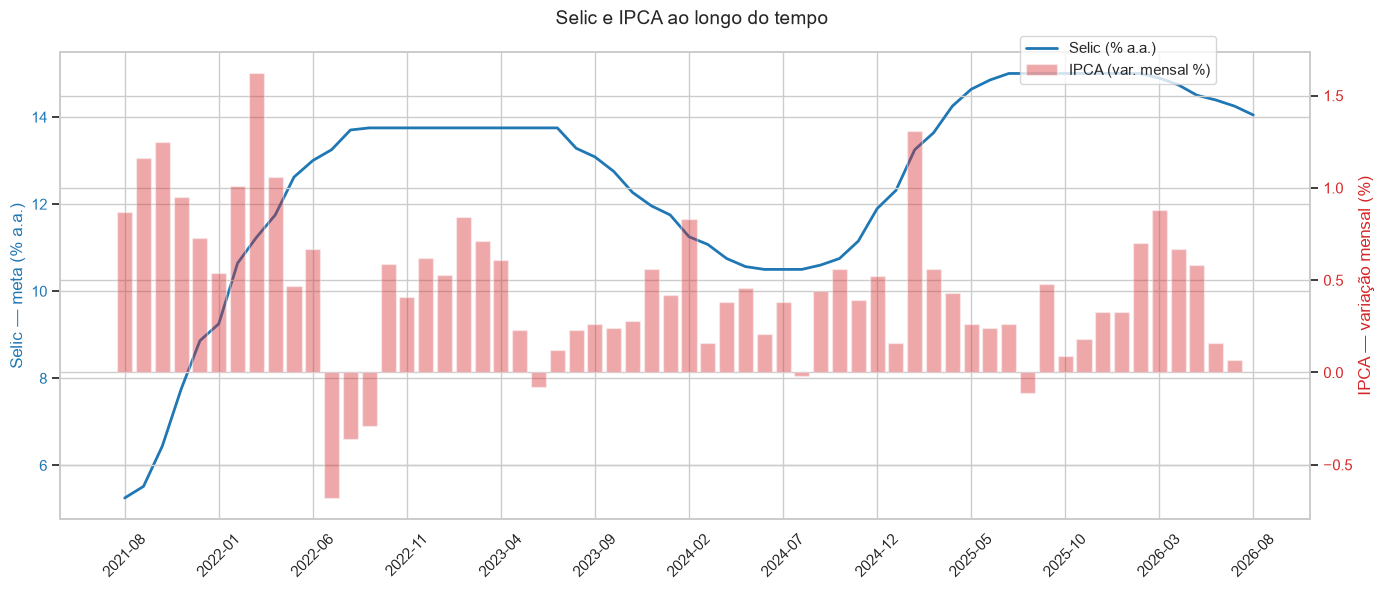

In [4]:
macro = df.drop_duplicates(subset="ano_mes")[["ano_mes", "selic_media", "ipca_variacao"]].sort_values("ano_mes")

fig, ax1 = plt.subplots(figsize=(14, 6))

color_selic = "#1f77b4"
color_ipca = "#d62728"

ax1.plot(macro["ano_mes"].astype(str), macro["selic_media"], color=color_selic, linewidth=2, label="Selic (% a.a.)")
ax1.set_ylabel("Selic — meta (% a.a.)", color=color_selic, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_selic)
ax1.tick_params(axis="x", rotation=45)
ax1.xaxis.set_major_locator(plt.MaxNLocator(15))

ax2 = ax1.twinx()
ax2.bar(macro["ano_mes"].astype(str), macro["ipca_variacao"], color=color_ipca, alpha=0.4, label="IPCA (var. mensal %)")
ax2.set_ylabel("IPCA — variação mensal (%)", color=color_ipca, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_ipca)

fig.suptitle("Selic e IPCA ao longo do tempo", fontsize=14)
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.95))
plt.tight_layout()
plt.show()

## Correlação entre retorno das ações e Selic / IPCA

Correlação de Pearson entre o retorno mensal de cada ticker e os indicadores macroeconômicos.

In [5]:
df_clean = df.dropna(subset=["retorno_mensal_pct"])

corr_selic = (
    df_clean.groupby("ticker")[["retorno_mensal_pct", "selic_media"]]
    .corr()
    .unstack()
    .iloc[:, 1]
    .reset_index()
)
corr_selic.columns = ["ticker", "corr_retorno_x_selic"]
corr_selic = corr_selic.sort_values("corr_retorno_x_selic", ascending=False).reset_index(drop=True)

print("Correlação: Retorno mensal x Selic")
display(corr_selic.style.format({"corr_retorno_x_selic": "{:.3f}"}).hide(axis="index"))

corr_ipca = (
    df_clean.dropna(subset=["ipca_variacao"])
    .groupby("ticker")[["retorno_mensal_pct", "ipca_variacao"]]
    .corr()
    .unstack()
    .iloc[:, 1]
    .reset_index()
)
corr_ipca.columns = ["ticker", "corr_retorno_x_ipca"]
corr_ipca = corr_ipca.sort_values("corr_retorno_x_ipca", ascending=False).reset_index(drop=True)

print("\nCorrelação: Retorno mensal x IPCA")
display(corr_ipca.style.format({"corr_retorno_x_ipca": "{:.3f}"}).hide(axis="index"))

Correlação: Retorno mensal x Selic


ticker,corr_retorno_x_selic
MGLU3.SA,0.233
^BVSP,0.232
ITUB4.SA,0.224
VALE3.SA,0.209
ABEV3.SA,0.157
CPFE3.SA,0.080
PETR4.SA,0.000
WEGE3.SA,-0.006



Correlação: Retorno mensal x IPCA


ticker,corr_retorno_x_ipca
VALE3.SA,-0.111
ABEV3.SA,-0.127
WEGE3.SA,-0.143
CPFE3.SA,-0.146
PETR4.SA,-0.249
MGLU3.SA,-0.281
ITUB4.SA,-0.370
^BVSP,-0.380


## Observações

**Retorno e volatilidade:**
- **PETR4** foi o grande destaque do período, com retorno acumulado de ~415% e retorno médio mensal de ~3,15%. Apesar da alta volatilidade (8,94%), o desempenho foi muito superior ao dos demais ativos.
- **MGLU3** foi o pior ativo: retorno acumulado de -97%, retorno médio mensal de -3,57% e, de longe, a maior volatilidade (21,45%). Reflete a forte queda de ações de crescimento/varejo no ciclo de alta de juros.
- **CPFE3** e **ITUB4** tiveram bons retornos acumulados (~115% e ~99%, respectivamente), com volatilidade moderada.
- **ABEV3** apresentou a menor volatilidade entre as ações individuais (5,75%), mas também o menor retorno acumulado positivo (~17%).
- O **Ibovespa (^BVSP)**, como benchmark, teve retorno acumulado de ~47% com a menor volatilidade geral (5,02%).

**Correlação com a Selic:**
- As correlações entre retorno mensal e Selic foram todas fracas (entre -0,01 e +0,23). Isso indica que, no nível mensal, a taxa Selic isoladamente não explica bem a variação dos retornos.
- MGLU3 teve a maior correlação positiva com a Selic (+0,23), o que pode parecer contraintuitivo — mas reflete que ambos subiram e caíram em momentos parecidos do ciclo, e não uma relação causal direta.
- WEGE3 e PETR4 tiveram correlação praticamente nula com a Selic.

**Correlação com o IPCA:**
- Todas as correlações retorno x IPCA foram negativas, variando de -0,11 (VALE3) a -0,38 (^BVSP). Isso sugere que meses com inflação mais alta tenderam a coincidir com retornos piores no mercado de ações.
- ITUB4 e o Ibovespa tiveram as correlações negativas mais fortes (~-0,37 e ~-0,38), indicando maior sensibilidade à inflação.